# Modelo ARIMA

Este cuaderno ajusta un modelo de tipo ARIMA para la serie de tiempo

## Librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pmdarima import auto_arima

## Configuraciones

In [2]:
# Configuracion base
PARQUET_PATH = "../data/conjuntos/datos_entrenamiento.csv"
DATE_COL = 'FechaMedicion'
TARGET_COL = 'Potencia'
TEST_SIZE = 6

## Carga de datos

In [3]:
df_train = pd.read_csv(PARQUET_PATH, parse_dates=[DATE_COL])
display(df_train.info())
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7790 entries, 0 to 7789
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Fase            7790 non-null   int64         
 1   FechaMedicion   7790 non-null   datetime64[ns]
 2   Voltaje         7790 non-null   float64       
 3   Corriente       7790 non-null   float64       
 4   Potencia        7790 non-null   float64       
 5   FactorPotencia  7790 non-null   float64       
 6   Frecuencia      7790 non-null   float64       
 7   EnergiaActiva   7790 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 487.0 KB


None

,Fase,FechaMedicion,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia,EnergiaActiva
0,1,2026-02-15 13:10:00,119.810,3.860,405.890,0.877,59.970,0.159
1,1,2026-02-15 13:20:00,120.038,3.536,369.512,0.874,59.962,0.222
2,1,2026-02-15 13:30:00,118.860,4.576,499.550,0.909,59.970,0.297
3,1,2026-02-15 13:40:00,118.330,8.893,1003.490,0.934,59.950,0.452
4,1,2026-02-15 13:50:00,119.230,6.094,696.680,0.937,59.960,0.585


## Modelado con AutoARIMA

Configuramos la serie de tiempo y ensayamos un modelo con datos correspondientes a una sola fase.

In [4]:
ts_1 = (
    df_train[df_train['Fase']== 1][[DATE_COL, TARGET_COL]]
    .dropna(subset=[DATE_COL])
    .sort_values(DATE_COL)
    .set_index(DATE_COL)[TARGET_COL]
)

Graficamos la serie de tiempo original a ser modelada

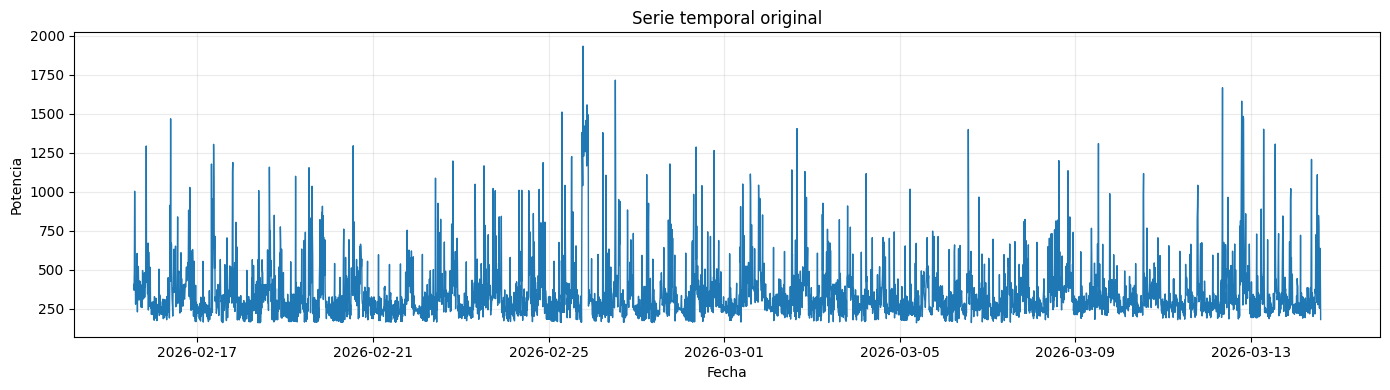

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(np.asarray(ts_1.index), np.asarray(ts_1.values, dtype=float), color="tab:blue", linewidth=1)
plt.title("Serie temporal original")
plt.xlabel("Fecha")
plt.ylabel(TARGET_COL)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Separamos los datos para visualizar una prueba. 

In [6]:
train = ts_1.iloc[:-TEST_SIZE]
test = ts_1.iloc[-TEST_SIZE:]

model = auto_arima(
    train,
    seasonal=True,
    m=6,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    maxiter=50,
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[6] intercept   : AIC=51716.751, Time=2.43 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=51953.134, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=51216.992, Time=1.61 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=51381.791, Time=1.37 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=57718.862, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[6] intercept   : AIC=51312.193, Time=0.08 sec
 ARIMA(1,0,0)(2,0,0)[6] intercept   : AIC=51216.044, Time=3.36 sec
 ARIMA(1,0,0)(2,0,1)[6] intercept   : AIC=inf, Time=5.08 sec
 ARIMA(1,0,0)(1,0,1)[6] intercept   : AIC=51223.220, Time=1.94 sec
 ARIMA(0,0,0)(2,0,0)[6] intercept   : AIC=51714.171, Time=2.60 sec
 ARIMA(2,0,0)(2,0,0)[6] intercept   : AIC=51095.754, Time=2.14 sec
 ARIMA(2,0,0)(1,0,0)[6] intercept   : AIC=51094.207, Time=0.79 sec
 ARIMA(2,0,0)(0,0,0)[6] intercept   : AIC=51129.915, Time=0.16 sec
 ARIMA(2,0,0)(1,0,1)[6] intercept   : AIC=51095.687, Time=1.84 sec
 ARIMA(2,0,0)(0,0,1)[6] i

In [9]:
test_pred_raw = model.predict(n_periods=6)
test_pred = pd.Series(np.asarray(test_pred_raw), index=test.index, name="pred_test")

mae = float((test - test_pred).abs().mean())
rmse = float(np.sqrt(((test - test_pred) ** 2).mean()))
mape = float((((test - test_pred).abs() / (test.abs() + 1e-9)).mean()) * 100)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

future_pred_raw = model.predict(n_periods=6)

ts_index = pd.DatetimeIndex(ts_1.index)
freq_for_future = pd.infer_freq(ts_index)
if freq_for_future is None:
    deltas = ts_index.to_series().diff().dropna()
    if len(deltas) == 0:
        raise ValueError(
            "No se pudo inferir frecuencia de la serie temporal."
        )
    freq_for_future = deltas.mode().iloc[0]


future_index = pd.date_range(start=ts_index.max(), periods=6 + 1, freq=freq_for_future)[1:]
future_forecast = pd.Series(np.asarray(future_pred_raw), index=future_index, name="pred_futuro")

predicciones = pd.concat([test.rename("real_test"), test_pred, future_forecast], axis=1)
display(predicciones.head(10))
display(predicciones.tail(10))

predicciones.to_csv("../predicciones_autoarima.csv", index=True)
print("Archivo guardado en ../predicciones_autoarima.csv")

MAE: 146.6001
RMSE: 179.6125
MAPE: 54.2448%


,real_test,pred_test,pred_futuro
2026-03-14 13:20:00,527.011,594.643777,NaN
2026-03-14 13:30:00,254.275,525.311650,NaN
2026-03-14 13:40:00,426.890,492.680501,NaN
2026-03-14 13:50:00,637.933,477.683925,NaN
2026-03-14 14:00:00,468.457,491.846187,NaN
2026-03-14 14:10:00,181.600,473.102516,NaN
2026-03-14 14:20:00,NaN,NaN,594.643777
2026-03-14 14:30:00,NaN,NaN,525.311650
2026-03-14 14:40:00,NaN,NaN,492.680501
2026-03-14 14:50:00,NaN,NaN,477.683925


,real_test,pred_test,pred_futuro
2026-03-14 13:40:00,426.890,492.680501,NaN
2026-03-14 13:50:00,637.933,477.683925,NaN
2026-03-14 14:00:00,468.457,491.846187,NaN
2026-03-14 14:10:00,181.600,473.102516,NaN
2026-03-14 14:20:00,NaN,NaN,594.643777
2026-03-14 14:30:00,NaN,NaN,525.311650
2026-03-14 14:40:00,NaN,NaN,492.680501
2026-03-14 14:50:00,NaN,NaN,477.683925
2026-03-14 15:00:00,NaN,NaN,491.846187
2026-03-14 15:10:00,NaN,NaN,473.102516


Archivo guardado en ../predicciones_autoarima.csv


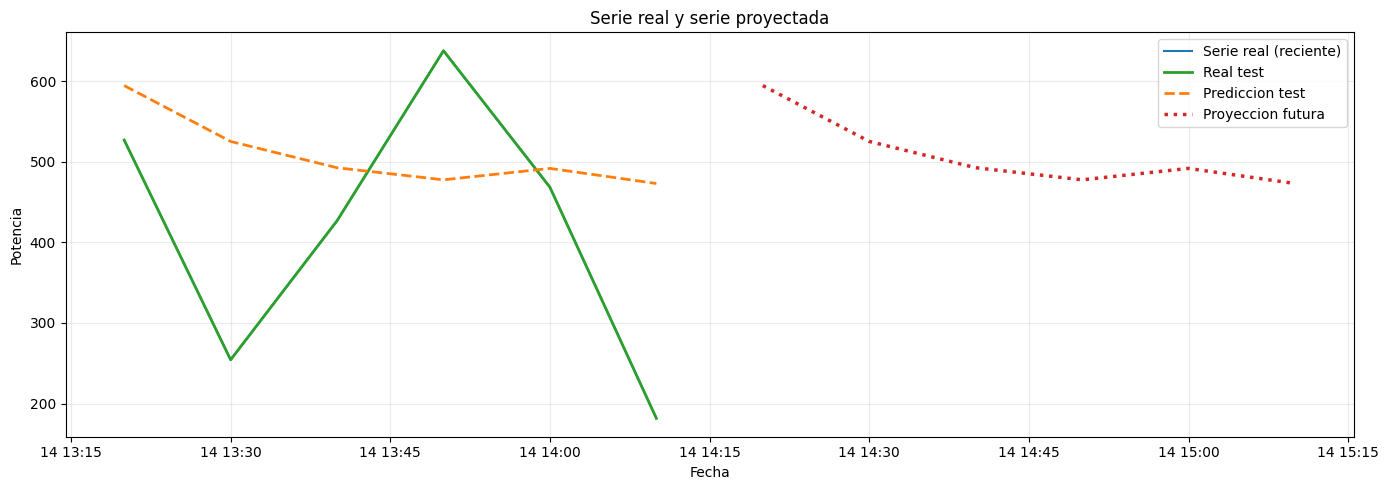

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Muestra un tramo reciente fijo para comparar con Prophet.
window = min(len(ts_1), 6)
ts_view = ts_1.iloc[-window:]

plt.plot(np.asarray(ts_view.index), np.asarray(ts_view.values, dtype=float), label="Serie real (reciente)", color="tab:blue", linewidth=1.5)
plt.plot(np.asarray(test.index), np.asarray(test.values, dtype=float), label="Real test", color="tab:green", linewidth=2)
plt.plot(np.asarray(test_pred.index), np.asarray(test_pred.values, dtype=float), label="Prediccion test", color="tab:orange", linestyle="--", linewidth=2)
plt.plot(np.asarray(future_forecast.index), np.asarray(future_forecast.values, dtype=float), label="Proyeccion futura", color="tab:red", linestyle=":", linewidth=2.5)

plt.title("Serie real y serie proyectada")
plt.xlabel("Fecha")
plt.ylabel(TARGET_COL)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()